In [70]:
import utils
import string
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

from sklearn.feature_extraction.text import TfidfVectorizer


[nltk_data] Downloading package stopwords to /home/lenovo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/lenovo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/lenovo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [71]:
print(utils.paragraph_danantara)

Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden 

In [72]:
sentences = sent_tokenize(utils.paragraph_danantara)

translator = str.maketrans('', '', string.punctuation)
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

for i in range(len(sentences)):
    #lower
    sentences[i] = sentences[i].lower()
    
    #remove punctuations
    sentences[i] = sentences[i].replace('\n\n', ' ').translate(translator)
    
    #remove stopwords
    sentences[i] = stopword_remover.remove(sentences[i])

print(sentences)

['jakarta badan pengelola investasi daya anagata nusantara bpi danantara siap mengawal realisasi investasi telah disepakati qatar', 'kesepakatan indonesia qatar merupakan buah kunjungan resmi presiden prabowo subianto doha', 'pemerintah republik indonesia pemerintah qatar menggelar diskusi menyepakati kemitraan strategis copartnership pengelolaan dana investasi indonesia akan berfokus berbagai sektor pembangunan', 'salah satu hasil utama kunjungan tersebut untuk membentuk dana investasi bersama senilai usd4 miliar', 'dana akan difokuskan pengembangan berbagai sektor antaranya termasuk tidak terbatas hilirisasi industri energi terbarukan fasilitas kesehatan indonesia', 'menyambut baik kepercayaan diberikan pemerintah qatar melalui pembentukan dana bersama kata ceo danantara indonesia rosan perkasa roeslani keterangan tertulis selasa 15 april 2025', 'presiden prabowo menyampaikan masingmasing negara berkontribusi sebesar usd2 miliar dana tersebut', 'dana akan dikelola bpi danantara bersa

In [73]:
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sentences)

features.shape

(16, 179)

In [74]:
words = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(features.toarray(), columns=words)

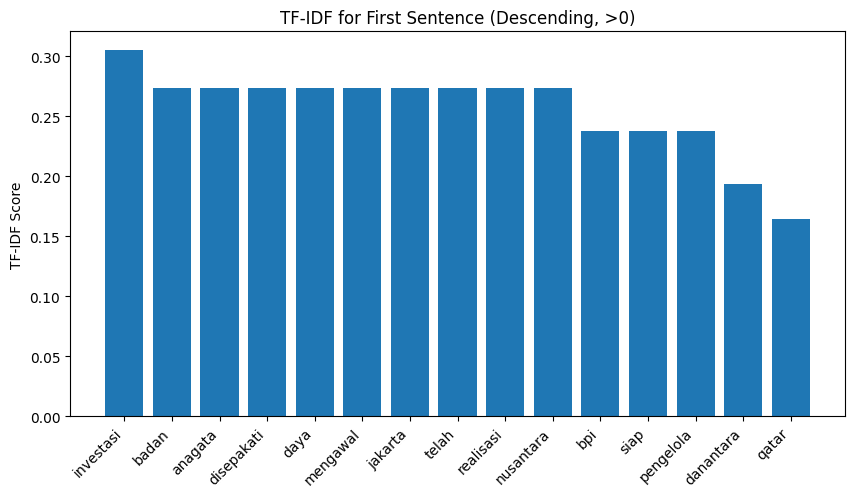

In [75]:
first_sentence_tfidf = tfidf_df.iloc[0]

first_sentence_tfidf = first_sentence_tfidf[first_sentence_tfidf > 0].sort_values(ascending=False)

# plot
plt.figure(figsize=(10, 5))
plt.bar(first_sentence_tfidf.index, first_sentence_tfidf.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF for First Sentence (Descending, >0)")
plt.show()